## Load Functions

In [4]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import time

In [5]:
def Marchenko_Pastur_significance_threshold(lam,var):
    sqrt = np.sqrt(lam)
    out1 = var*(1-sqrt)**2
    out2 = var*(1+sqrt)**2
    return (out1,out2)
    
def Marchenko_Pastur_distribution(lambda_min,lambda_max,lam,var):
    x_vector = np.linspace(lambda_min,lambda_max,10000)
    dx = x_vector[1]-x_vector[0]
    pdf = 1/(2*np.pi*var) * np.sqrt((lambda_max-x_vector)*(x_vector-lambda_min))/(lam*x_vector)
    return x_vector,pdf

In [6]:
def plot_matrix(matrix,cmap = 'RdBu',max_value=None,min_value=None,aspect=None,tight_layout=True,figsize=None,
               xticks = [],x_ticklabels = [],x_orientation=0,x_alignment='center',
                yticks = [],y_ticklabels = [],title=None,
               xlabel=None,ylabel=None,
                set_log_xscale=False,set_log_yscale=False,scale=None,
               cbar_label = None,x_fontsize=10,y_fontsize=10,
               savefig=False,format='png',out_dir='',data_name = '',
               draw_special_diagonal=False,diagonal_color='k'):

    if max_value==None:
        max_value = 1.1*np.max(matrix)
    if min_value==None:
        min_value = 1.1*np.min(matrix)
    norm_value = (colors.TwoSlopeNorm(vcenter=0,vmin=min_value,vmax=max_value) if cmap=='RdBu' else None)
    if scale=='log': norm_value='log'
    fig,ax = plt.subplots(figsize=figsize)
    heatmap = ax.imshow(
               matrix,
               cmap=cmap,
               aspect=aspect,
               norm=norm_value,
               vmax = (max_value if cmap=='Reds' or cmap=='Blues' else None),
                       )
    cbar = fig.colorbar(heatmap,label=cbar_label)
    if draw_special_diagonal ==True:
        for i in range(min(np.shape(matrix)[0],np.shape(matrix)[1])):
            rect = patches.Rectangle(
                (i - 0.5, i - 0.5),  # bottom-left corner (cell boundaries in imshow coordinates)
                1, 1,                # width, height (one cell)
                facecolor="black",
                edgecolor="none",
                zorder=3             # draw above the image
            )
            ax.add_patch(rect)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels(y_ticklabels,fontsize=y_fontsize)
    ax.set_xticklabels(x_ticklabels,rotation=x_orientation,ha=x_alignment,
                      fontsize=x_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if set_log_xscale == True:
        ax.set_xscale('log')
    if set_log_yscale==True:
        ax.set_yscale('log')
    if tight_layout==True:
        plt.tight_layout()
    if savefig==True:
        plt.savefig(os.path.join(out_dir,data_name)+str('.{}'.format(format)),format=format,dpi=300,transparent=True)
    plt.show()  

    return

In [7]:
from numba import njit

@njit
def species_growth_rates(R_vec,n_vec,
                 growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                ):
    ''' Growth of the species as a function of the resource abundances: g_i^\alpha(\vec{R},\vec{n})
    By default, we use nR/(1+R) on all resources.
    '''
    R_part = R_vec/(1+R_vec)
    outer = np.outer(R_part,n_vec) #Shape (N_R,N_n)
    outer = outer*growth_choices
    
    # if np.random.random()<1e-3:
    #     print('growth_rates',np.sum(outer>1e-3))
    #     print(outer[0,:])

    ''' Calculate also the total species growth rates '''
    species_total_growth_rate = np.sum(outer,axis=0) #shape (N_species)
    return outer,species_total_growth_rate

@njit
def resource_depletion_production(R_vec,n_vec,
                   total_species_growth_rate, #Shape (N_species)
                                  inv_yields):

    '''
    Calculates g_i^alpha*1/Y_i^\alpha
    '''

    resource_changes = total_species_growth_rate[None,:]*inv_yields #is shape (1,N_res,N_species). I don't know why there is the one

    # if np.random.random()<1e-3:
    #     print('production terms',resource_changes)
    
    return resource_changes

@njit
def d_resources(R_vec,n_vec,
               entry_rates,
                total_growth_rates,
                inv_yields):

    entry = entry_rates #shape (N_res)
    res_changes = resource_depletion_production(R_vec,n_vec,total_growth_rates,inv_yields)

    # if np.random.random()<1e-3:
    #     print('res_changes',res_changes)

    consumption_production = -np.sum(res_changes,axis=1) #Shape N_resource

    return entry+consumption_production

@njit
def d_species(n_vec,growth_rates):

    species_growth = np.sum(growth_rates,axis=0)

    return species_growth    
    
    
    
    

In [8]:

dataset_name = '2025.12.18.CR_batch_like'
if os.path.exists(dataset_name)==False:
    os.mkdir(dataset_name)

In [9]:
''' System constants '''
N_species = 20
N_resources = 1
independent_species_cutoff = 100 #N_species #species beyond this cutoff exist independently of all others and are akin to noise
nsteps = 30000
dt = 0.005
dilution = 0.1

set_random_seed = True
if set_random_seed:
    np.random.seed(0)

In [12]:


''' Resource entries '''
entry_rates = np.zeros(N_resources)
how_many_suplied_resources = int(np.round(N_resources/5)+1e-4)
how_many_supplied_resources = N_resources
# how_many_supplied_resources = 5
if N_resources>1:
    entered_res = np.random.choice(min(independent_species_cutoff,N_resources),
                                   size=how_many_supplied_resources,
                                   replace=False)
else:
    entered_res = np.array([0])

if dataset_name == 'two_resources_one_high_one_low':
    entered_res = np.array([0,1])

# entered_res = np.random.choice(20,size=how_many_supplied_resources,replace=False)
entry_rates[entered_res] = np.abs(np.random.normal(0,1,size=len(entered_res))) #gaussian(0,1) 
if independent_species_cutoff<N_resources:
    entry_rates[independent_species_cutoff:] = np.abs(np.random.normal(0,1,size=N_species-independent_species_cutoff))#such that independent species also grow, in the absence of interactions with others.
# entry_rates[:independent_species_cutoff] = 1 #to make all species the same for the independent dataset

''' Inverse yields and growth preferences '''
inv_yields = np.zeros((N_resources,N_species))#np.random.normal(0,1,N_resources*N_species).reshape((N_resources,N_species))
growth_choices = np.zeros((N_resources,N_species))
for sp in range(N_species):

    
    if sp<independent_species_cutoff:
        if dataset_name == 'single_resource_high_fluctuation': res = 0; inv_yields[res,sp] = 1.0; growth_choices[res,sp] = 1.0; continue
        if dataset_name == 'two_resources_one_high_one_low':
            res  = int(sp//(N_species/2))
            inv_yields[res,sp] = 1.0
            growth_choices[res,sp] = 1.0
            continue

        eats_single_resource = True
        if eats_single_resource:
            ''' If eating one resource '''
            res = sp//5 #if guilded
            inv_yields[res,sp] = 1.0 #consumption yield. You can add some noise for the CR-batch-like  simulation.
            growth_choices[res,sp] = 1.0 #species eats the chosen resource
        else:
            ''' If eating multiple resources '''
            how_many_res_eaten = 4-1
            eaten_resources = np.random.choice(sp,size= min(how_many_res_eaten,sp),replace=False)
            growth_choices[eaten_resources,sp] = 1.0
            inv_yields[eaten_resources,sp] = 1.0
            growth_choices[sp,sp] = 1.0; inv_yields[sp,sp] = 1.0
    else:
        res = sp%N_resources
        growth_choices[res,sp] = 1.0 #species eats the chosen resource
        inv_yields[res,sp] = 1.0 #consumption yield
    
   
    
    

    
    if sp>=independent_species_cutoff:
        ''' For independent species, give them a yield that makes them scale across several orders of magnitude '''
        if independent_species_cutoff<N_resources:
            inv_yields[res,sp] = 10**(2*np.random.random()) #to make independent species span several orders of magnitude
        else:
            inv_yields[res,sp] = 1.0 #all independent species have the same yield. You can then rescale their abundances to match other species abundances.

    if sp<independent_species_cutoff:
        produceable_species = [2] if sp//7<2 else [] #For CR-batch-like simulations
        
        if len(produceable_species)>0:
            how_many_secreted_resources = 1
            produced_res = np.random.choice(produceable_species,size=how_many_secreted_resources,
                                           ) #Resources produced by the species
            produced_res = produced_res[produced_res<N_resources]
            produced_res = produced_res%N_resources
            
            # produced_res = produced_res[produced_res<independent_species_cutoff] #cannot produce resources that have no corresponding species
            inv_yields[produced_res,sp] = -1/how_many_secreted_resources #-0.5 #resource is produced
        




In [13]:
inv_yields_complete = np.copy(inv_yields)
growth_choices_complete = np.copy(growth_choices)

''' Dump these arrays to they can be loaded from the functions.py file '''

with open('inv_yields_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(inv_yields_complete,f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(growth_choices_complete,f)
    f.close()

## Data analysis

In [10]:
with open('species_traces_full.{}.dat'.format(dataset_name),'rb') as f:
    species_traces_full = pickle.load(f)
    f.close()
    
species_traces = np.copy(species_traces_full)
with open('resource_traces_full.{}.dat'.format(dataset_name),'rb') as f:
    resource_traces_full = pickle.load(f)
    f.close()
resource_traces = np.copy(resource_traces_full)

with open('supplied_resources.{}.dat'.format(dataset_name),'rb') as f:
    supplied_resources = pickle.load(f)
    f.close()

with open('inv_yields_complete.{}.dat'.format(dataset_name),'rb') as f:
    inv_yields_complete = pickle.load(f)
    inv_yields = np.copy(inv_yields_complete)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'rb') as f:
    growth_choices_complete = pickle.load(f)
    f.close()

print('Supplied resources',supplied_resources)

Supplied resources [0, 1]


In [11]:
print('Total sample abundance in first 10 samples \n',np.sum(species_traces_full,axis=1)[:10])

Total sample abundance in first 10 samples 
 [141.98588787 259.47215246 237.82181179 201.93023731 304.10452433
 153.95145859 142.78947572 218.43846475 275.83471551 198.88584425]


[0, 1]
[0.00979149 0.01086802 0.01226579]


Text(0, 0.5, 'n')

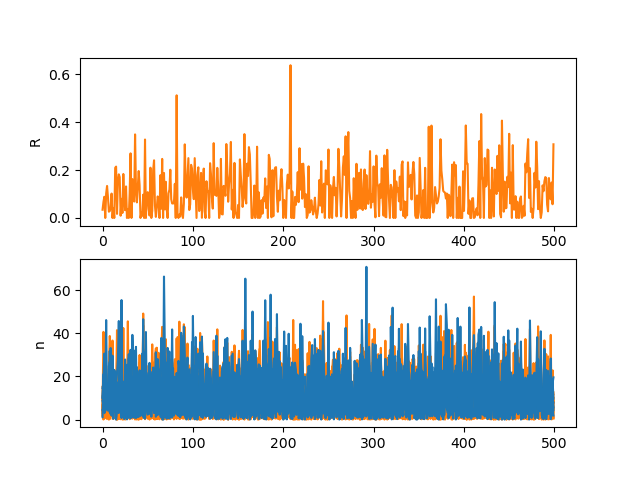

In [12]:
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots(2,1)
# ax[0].plot(resource_traces_full[:,[50,51,52]])
for res in range(N_resources):
    if res in supplied_resources:
        ax[0].plot(resource_traces_full[:,res],'tab:orange')
    else:
        ax[0].plot(resource_traces_full[:,res],'tab:blue')
res_vars = np.var(resource_traces_full,axis=0)
print(supplied_resources)
print(res_vars)
ax[0].set_ylabel('R')
# ax[1].plot(species_traces_full)
for s in range(N_species):
    if np.sum(inv_yields[supplied_resources,s])>0: #species consumes entered resource
        ax[1].plot(species_traces_full[:,s],'tab:orange')
    else:
        ax[1].plot(species_traces_full[:,s],'tab:blue')
ax[1].set_ylabel('n')
# ax[1].set_yscale('log')
# ax[0].set_yscale('log')

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


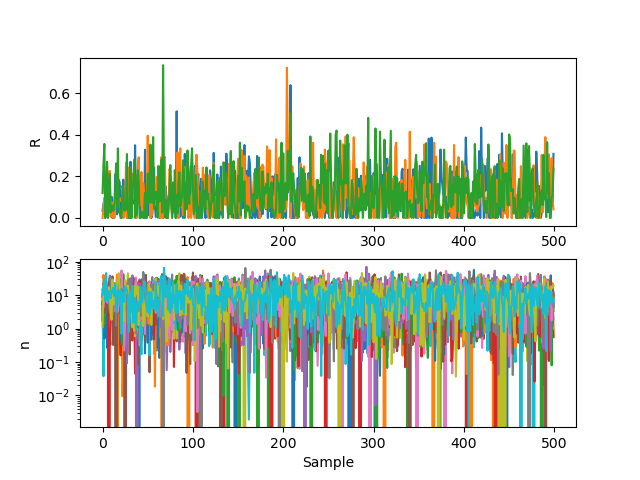

In [13]:
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots(2,1)
ax[0].plot(resource_traces_full)
ax[0].set_ylabel('R')
ax[1].plot(species_traces_full)
ax[1].set_ylabel('n')
ax[1].set_yscale('log')
# ax[0].set_yscale('log')
ax[1].set_xlabel('Sample')

print(np.mean(species_traces_full,axis=0)>1)

In [14]:
np.shape(species_traces_full)[0]

500

In [15]:
occupancy = np.array(np.sum(species_traces_full>0,axis=0))
# occupancy = occupancy/ 60
print(occupancy)

[497 496 495 496 499 495 496 498 497 498 497 496 496 495 499 498 499 498
 495 499]


<BarContainer object of 20 artists>

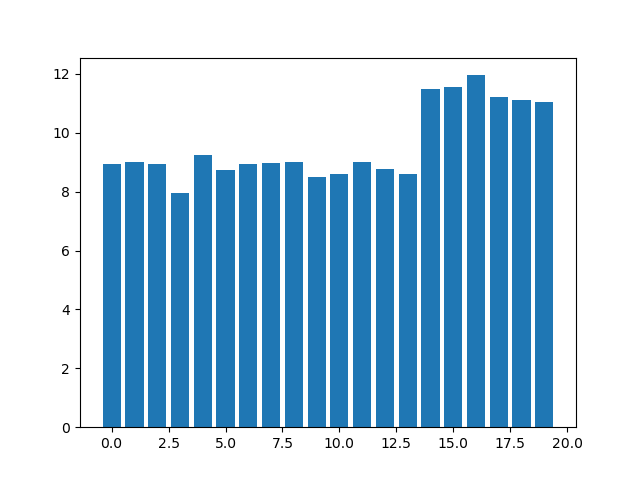

In [16]:
fig,ax = plt.subplots()
ax.bar(np.arange(N_species),
       np.mean(species_traces_full[-1000:,:],axis=0))
# ax.set_yscale('log')

0 1 True True
1 2 True False
2 3 False False
3 4 False False
4 5 False False
5 6 False False
6 7 False False
7 8 False False
8 9 False False
9 10 False False
10 11 False False
11 12 False False
12 13 False False
13 14 False False
14 15 False False
15 16 False False
16 17 False False
17 18 False False
18 19 False False
19 20 False False
20 21 False False


IndexError: index 20 is out of bounds for axis 1 with size 20

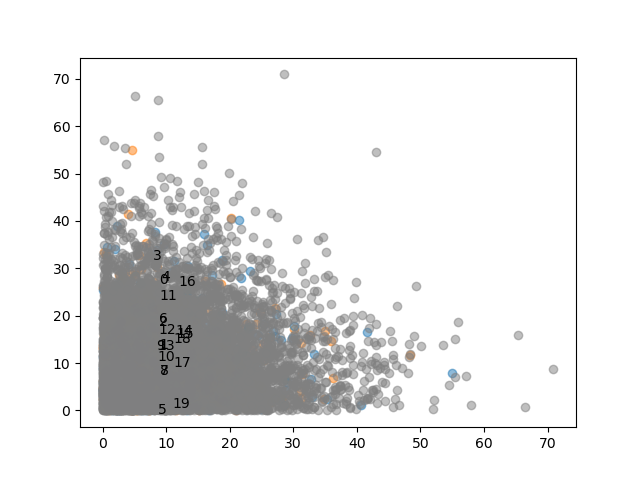

In [17]:
''' Plot abundances of cross-fed species pairs to check, by eye, if they are correlated or not '''
# species_that_feed_on_external_resources = np.arange(N_species)[(entry_rates>0.1) & (np.arange(N_species)<independent_species_cutoff)]
from matplotlib import colormaps as cmaps

fig,ax = plt.subplots()
cmap = cmaps.get_cmap('Set3')
for s in range(independent_species_cutoff):#species_that_feed_on_external_resources
    is_entered = (s in supplied_resources)
    is_next_entered = (s+1 in supplied_resources)
    
    # color = 'lightgray'
    if is_entered and (is_next_entered==False): 
        color = 'tab:blue'
    elif is_entered and is_next_entered: 
        color='tab:orange'
    elif is_entered==False and is_next_entered: 
        color='tab:red'
    else: 
        
        color='gray'
        # color = np.random.random(size=3); 
        # print(color)
        # color = cmap(s)
    print(s,s+1,is_entered,is_next_entered)
    # print(s,entry_rates[s])
    ax.scatter(species_traces_full[:,s],
               species_traces_full[:,(s+1)%N_species],
              color=color,
              alpha=0.5)
    ax.text(np.mean(species_traces_full[:,s]),
            np.mean(species_traces_full[:,(s+1)%N_species])+10*np.random.normal(),
            s)

ax.set_xlabel(r'$x_i$')
ax.set_ylabel(r'$x_{i+1}$')
plt.savefig('x_i_vs_x_i+1.{}.png'.format(dataset_name),format='png',transparent=True)
plt.savefig('x_i_vs_x_i+1.{}.pdf'.format(dataset_name),format='pdf',transparent=True)

In [18]:
np.shape(species_traces_full)

(500, 20)

# Correlation analyses

In [19]:
''' Look at autocorrelation decay '''
autocorrelations = []
for s in range(N_species):
    trace = species_traces[:,s]
    sp_autocorrelations = []
    for dt in range(10000):
        rolled_trace = np.roll(trace,-dt)
        if dt!=0:
            autocorrelation = np.corrcoef(trace[:-dt],rolled_trace[:-dt])[0,1] #you must ignore the last elements
        else:
            autocorrelation = np.corrcoef(trace[:],rolled_trace[:])[0,1] #you must ignore the last elements
        sp_autocorrelations.append(autocorrelation)
    autocorrelations.append(sp_autocorrelations)

autocorrelations = np.array(autocorrelations).T





C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\lib\function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Text(0, 0.5, '$c(x(t),x(t+\\tau))$')

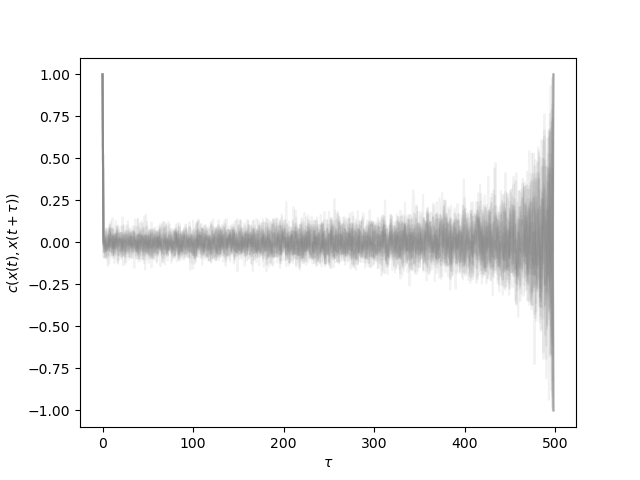

In [20]:
plt.close('all')
fig,ax = plt.subplots()
ax.plot(autocorrelations,alpha=0.1,color='gray')
# ax.set_xlim(left=len(autocorrelations)//2)
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$c(x(t),x(t+\tau))$')

Thought:

the above autocorrelations should decay slowly if we take the original species traces, because the abundance of a species at time t+dt will be a change wrt the abundance at time t and so the two will not be completely independent.

If, instead, we take the shuffled (possibly but not necessarily subsampled) species traces that result from the next lines of code, then the autocorrelation is exactly 1 for dt=0 and 0 otherwise. Precisely because we have killed these time correlations between samples. YET, if two species were both at high abundance at time t and t+dt, then because they have time-correlations with themselves, they will appear as being correlated to one another, even after the samples have been shuffled. For this matter, it is imperative that the simulations are run independently and then we only take one sample from each simulation.

In [21]:
rescale_independent_species_abundances = False
if rescale_independent_species_abundances:
    ''' Rescale independent species abundances such that they span the same magnitudes as the dependent (<indep_species_cutoff) species '''
    mean_abundance = np.mean(species_traces[:,:independent_species_cutoff],axis=0)
    lowest_abundance = np.min(mean_abundance)
    highest_abundance = np.max(mean_abundance)
    mean_abundance = np.mean(mean_abundance)

    mean_indep_abundance = np.mean(species_traces[:,independent_species_cutoff:],axis=0)
    lowest_indep_abundance = np.min(mean_indep_abundance)
    highest_indep_abundance = np.max(mean_indep_abundance)
    mean_indep_abundance = np.mean(mean_indep_abundance)

    log_abus = np.log(species_traces[:,independent_species_cutoff:])
    log_abus = log_abus-np.log(mean_indep_abundance)+np.log(mean_abundance)
    log_abus *= (np.log(highest_abundance)-np.log(lowest_abundance))/(np.log(highest_indep_abundance)-np.log(lowest_indep_abundance))
    
    species_traces[:,independent_species_cutoff:] = np.exp(log_abus)

    

    

In [22]:
''' If you want N_species>N_samples, do a random subsampling of the dataset '''
''' You can use also if you want to shuffle sample indices so as to lose time correlations between samples '''
subsample_dataset = False
random_subsampling = False
if subsample_dataset:
    last_T = 10000
    how_many_samples = round(last_T/5)#np.shape(species_traces)[1]//5
    
    # how_many_samples = round(N_species/5) #standard choice
    # how_many_samples = round(N_species/3) 
    if random_subsampling:
        if which_option == 'A':
            which_samples = -np.random.choice(np.arange(1,last_T),size=how_many_samples-1,replace=False)
        elif which_option == 'C':
            which_samples = np.random.choice(np.shape(species_traces)[0],size=how_many_samples,replace=False)
    else:
        which_samples = np.arange(-how_many_samples,-1)
    print(which_samples)
    species_traces = species_traces_full[which_samples,:]
    print(np.shape(species_traces))

In [23]:
relative_abundances_bool = False
if relative_abundances_bool:
    data = species_traces/np.sum(species_traces,axis=1)[:,None] #Relative Abundance Data
else:
    data  = species_traces #Absolute abundance data
# data = data[-2000:,means>0.002]
means = np.mean(data,axis=0)
vars = np.var(data,axis=0)
N_species = np.shape(data)[1]

In [24]:
independent_species_cutoff

100

beta_inferred 1.1456527617121388


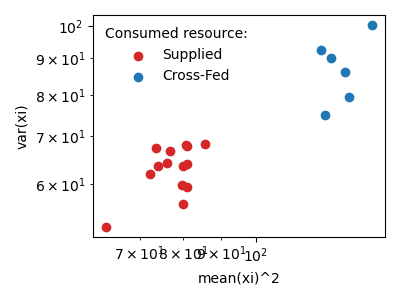

In [25]:
''' Check Taylor's Law '''
# means = np.mean(species_traces,axis=0)#/np.sum(species_traces,axis=1)[:,None],axis=0)
# vars = np.var(species_traces,axis=0)#/np.sum(species_traces,axis=1)[:,None],axis=0)
fig, ax = plt.subplots(figsize=(4,3))
plotted_labels = []
for s in range(N_species):
    if s<independent_species_cutoff:
        species_inv_yields = inv_yields[:,s]
        eats_supplied_resource = np.sum(species_inv_yields[supplied_resources]>0)>0
        if eats_supplied_resource:
            color = 'tab:red'
            label = 'Supplied'
            label = label if label not in plotted_labels else None
        else:
            color = 'tab:blue'
            label = 'Cross-Fed'
            label = label if label not in plotted_labels else None
    else:
        color = 'tab:orange'
        label = 'Independent'
        label = label if label not in plotted_labels else None
    ax.scatter(means[s]**2,vars[s],
              c=color,
              label=label)
    plotted_labels.append(label)
beta_inferred = np.mean(means**2/vars)
print('beta_inferred',np.sqrt(beta_inferred))
ax.legend(loc='best',frameon=False,title='Consumed resource:')
ax.set_xlabel('mean(xi)^2')
ax.set_ylabel('var(xi)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('Taylor_law.{}.png'.format(dataset_name),format='png',transparent=True)
plt.savefig('Taylor_law.{}.pdf'.format(dataset_name),format='pdf',transparent=True)


In [26]:
''' Argsort species by mean abundance if necessary. '''
# argsorted_species = np.flip(np.argsort(means))[:N_species]
# data = data[:,argsorted_species]
# means = means[argsorted_species]
# vars = vars[argsorted_species]

# ''' Keep only growth_rates and inv_yields for the species that survive the simulation '''
# growth_choices = growth_choices[:,argsorted_species]
# inv_yields = inv_yields[:,argsorted_species]


sample_abus = np.sum(data,axis=1)
N_mean = np.mean(sample_abus)
sigma_N  = np.std(sample_abus)

print('Total sample abundances: {:.3f}+-{:.3f}'.format(N_mean,sigma_N))

Total sample abundances: 191.579+-57.246


In [27]:
''' Create dummy dataset from an unstructured identity covariance matrix '''
generate_unstructured_dataset = False
if generate_unstructured_dataset:
    ''' Multivariate Gaussian Dataset '''
    # Sigma = np.eye(N_species)
    # data = np.random.multivariate_normal(mean = [0]*N_species, cov = Sigma, size = how_many_samples)
    ### Leads to a Marchenko-Pastur distribution

    # ''' Multivariate Truncated Gaussian Dataset '''
    # data[data<0] = -data[data<0] #make positive by reflextion the previous lines

    ### Leads to a Marchenko-Pastur distribution

    ''' Independent draws from an exponential distribution '''
    data = np.random.exponential(scale = 1.0, size=(how_many_samples,N_species))
    ### Leads to a Marchenko-Pastur distribution

    ''' Independent draws from a Gamma distribution '''
    data = np.random.gamma(1,scale=1,size=(how_many_samples,N_species))
    ### Leads to a Marchenko-Pastur distribution
    


1.1552351812331194


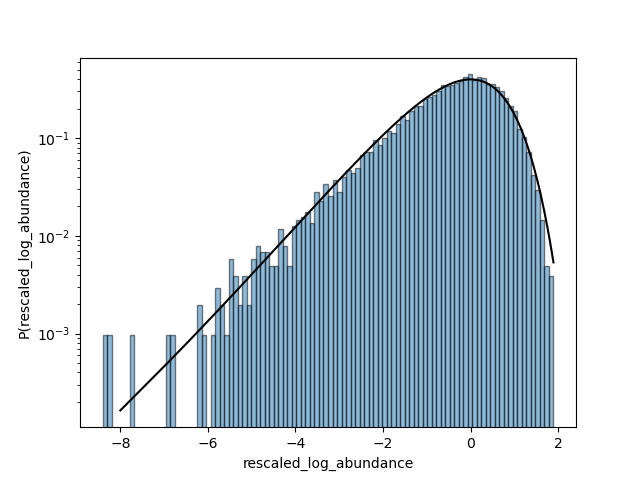

In [28]:
''' Check Gamma Distributions '''
from scipy.stats import gamma

rescaled_abundances = data/np.mean(data,axis=0)[None,:]


gamma_params = gamma.fit(rescaled_abundances.flatten(),2.5)
gamma_func = gamma(a=gamma_params[0],loc=gamma_params[1],scale=gamma_params[2])
print(gamma_params[0])

# gamma_func.fit(rescaled_abundances.flatten())


log_rescaled_abundances = np.log(rescaled_abundances[rescaled_abundances>0])

counts,bins = np.histogram(log_rescaled_abundances.flatten(),bins=100,
                          density=True)
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

fig,ax = plt.subplots()
ax.bar(bin_centers,
       counts,
       width= dbin,
       alpha=0.5,edgecolor='k')
x_vect = np.linspace(max(np.min(rescaled_abundances),np.exp(-8)),np.max(rescaled_abundances),10000)

gamma_pdf = gamma_func.pdf(x_vect)

ax.plot(np.log(x_vect),gamma_pdf*x_vect,'k')
ax.set_yscale('log')
ax.set_xlabel('rescaled_log_abundance')
ax.set_ylabel('P(rescaled_log_abundance)')
plt.savefig('Gamma_distribution.{}.png'.format(dataset_name),format='png',transparent=True)
plt.savefig('Gamma_distribution.{}.pdf'.format(dataset_name),format='pdf',transparent=True)

In [29]:
np.shape(data)
data_nonrescaled = np.copy(data)

In [30]:
''' Rescale abundances by their own standard deviation, as in z-scoring but without subtracting the mean '''
data  = data_nonrescaled/np.std(data_nonrescaled,axis=0)[None,:]
data = np.copy(data_nonrescaled)

In [31]:
left_eigs,svds,right_eigs = np.linalg.svd(data.T)
print(svds)

[1007.49442188  239.52854972  235.99541981  227.14659185  218.07629823
  207.81277071  199.28417376  190.26873322  183.34131407  178.962222
  177.89794039  167.85216065  167.04182938  161.06776456  156.56807149
  153.83589797  146.50303473  140.76292942  136.84473179   47.65316246]


In [37]:

cov_matrix = np.corrcoef(data.T)

true_eigvals,true_eigvects = np.linalg.eigh(cov_matrix)

argsorted_true_eigvals = np.argsort(true_eigvals)
true_eigvals=true_eigvals[argsorted_true_eigvals]
true_eigvects = true_eigvects[:,argsorted_true_eigvals]

true_eigvals = np.real(true_eigvals)
true_eigvects = np.real(true_eigvects)

''' Correlation matrix across samples '''
# cov_matrix_samples = np.corrcoef(data)#cov_matrix.T#np.corrcoef(data)

# true_eigvals_samples,true_eigvects_samples = np.linalg.eigh(cov_matrix_samples)

# argsorted_true_eigvals_samples = np.argsort(true_eigvals_samples)
# true_eigvals_samples=true_eigvals_samples[argsorted_true_eigvals_samples]
# true_eigvects_samples = true_eigvects_samples[:,argsorted_true_eigvals_samples]

# true_eigvals_samples = np.real(true_eigvals_samples)
# true_eigvects_samples = np.real(true_eigvects_samples)

' Correlation matrix across samples '

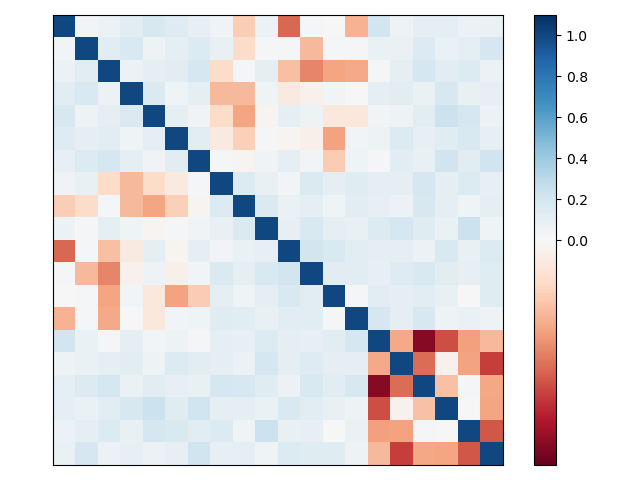

In [38]:
plot_matrix(cov_matrix,
           # cmap='Blues'
           )

In [39]:
true_eigvals.shape

(20,)

In [40]:
N_randomizations = 100
dummy_eigvals = []
dummy_eigvects = []
for kk in range(N_randomizations):
        
    dummy_subset = np.copy(data)
    shuffled_comms = np.arange(np.shape(data)[0])
    shuffled_species = np.arange(np.shape(data)[1])
    for s in range(N_species):
        ''' Shuffle Abundances of one species across samples '''
        np.random.shuffle(shuffled_comms) #shuffled community indices
        dummy_subset[:,s] = dummy_subset[shuffled_comms,s]
    # for c in range(np.shape(data)[0]):
    #     ''' Shuffle abundnaces of species within each sample, which should keep the large fluctuations in a sample '''
    #     np.random.shuffle(shuffled_species)
    #     dummy_subset[c,:] = dummy_subset[c,shuffled_species]
        
    print('{}, with shape ({},{})'.format(kk,np.shape(dummy_subset)[0],np.shape(dummy_subset)[1]))
    
    cov_dummy = np.corrcoef(dummy_subset.T)

    eigvals,eigvects = np.linalg.eigh(cov_dummy)

    for eigval in eigvals: dummy_eigvals.append(eigval)
    for eigvect in eigvects.T: dummy_eigvects.append(eigvect)

0, with shape (500,20)
1, with shape (500,20)
2, with shape (500,20)
3, with shape (500,20)
4, with shape (500,20)
5, with shape (500,20)
6, with shape (500,20)
7, with shape (500,20)
8, with shape (500,20)
9, with shape (500,20)
10, with shape (500,20)
11, with shape (500,20)
12, with shape (500,20)
13, with shape (500,20)
14, with shape (500,20)
15, with shape (500,20)
16, with shape (500,20)
17, with shape (500,20)
18, with shape (500,20)
19, with shape (500,20)
20, with shape (500,20)
21, with shape (500,20)
22, with shape (500,20)
23, with shape (500,20)
24, with shape (500,20)
25, with shape (500,20)
26, with shape (500,20)
27, with shape (500,20)
28, with shape (500,20)
29, with shape (500,20)
30, with shape (500,20)
31, with shape (500,20)
32, with shape (500,20)
33, with shape (500,20)
34, with shape (500,20)
35, with shape (500,20)
36, with shape (500,20)
37, with shape (500,20)
38, with shape (500,20)
39, with shape (500,20)
40, with shape (500,20)
41, with shape (500,20)
42

0.04
lambda_min = 0.6400000000000001
3 2 15


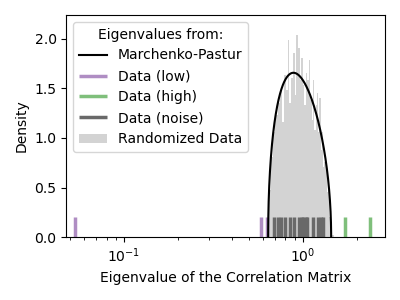

In [42]:
counts,bins = np.histogram(dummy_eigvals,density=True,
                           # bins=150,
                           bins=int(np.sqrt(len(dummy_eigvals)))
                          )
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2


'''
Draw the Marchenko-Pastur distribution
'''
lam = np.shape(data)[1]/np.shape(data)[0]
print(lam)
var=1#np.mean(np.var(data,axis=0))#1.0 #as long as we consider data normalized by 1/std(x), such that we have a correlation matrix.
marchenko_pastur_min,marchenko_pastur_max = Marchenko_Pastur_significance_threshold(lam,var)
eig_x_vector,marchenko_pastur_distr = Marchenko_Pastur_distribution(marchenko_pastur_min,marchenko_pastur_max,lam,var)
print('lambda_min = {}'.format(marchenko_pastur_min))

%matplotlib widget
fig,ax = plt.subplots(figsize=(4,3))
counts,bins = np.histogram(dummy_eigvals,density=True,
                           # bins=150,
                           bins=int(np.sqrt(len(dummy_eigvals)))
                          )
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

ax.bar(bin_centers[:],counts[:],
       width=dbin*1.02,edgecolor=None,
       color = 'lightgray',
       zorder=0,
      label='Randomized Data')
ax.plot(eig_x_vector,marchenko_pastur_distr,'k',label='Marchenko-Pastur')
''' Plot the eigenvalues from the dataset '''
low_eigvals = true_eigvals[true_eigvals<marchenko_pastur_min]; true_lowvar_eigvects = true_eigvects[:,true_eigvals<marchenko_pastur_min]
if np.shape(data)[0]<np.shape(data)[1]: #less samples than species
    true_lowvar_eigvects = true_lowvar_eigvects[:,low_eigvals>1e-10] #keep nonzero eigenvalues
    low_eigvals = low_eigvals[low_eigvals>1e-10]
high_eigvals = true_eigvals[true_eigvals>marchenko_pastur_max]; true_highvar_eigvects = true_eigvects[:,true_eigvals>marchenko_pastur_max]
noise_eigvals = true_eigvals[(marchenko_pastur_min<= true_eigvals) & (true_eigvals <= marchenko_pastur_max)]
ax.vlines(low_eigvals,0,0.1*np.max(counts[1:]),
          colors=[175/255,141/255,195/255],#'tab:red',
          linewidth=2.5,zorder=0,
         label='Data (low)')
ax.vlines(high_eigvals,0,0.1*np.max(counts[1:]),
          colors=[127/255,191/255,123/255],#'tab:green',
          linewidth=2.5,zorder=0,
         label='Data (high)')
ax.vlines(noise_eigvals,0,0.1*np.max(counts[1:]),
          colors='dimgray',#'tab:orange',
          linewidth=2.5,zorder=0,
         label='Data (noise)')

ax.legend(loc='upper left',frameon=True,
          title='Eigenvalues from:')
ax.set_xlabel('Eigenvalue of the Correlation Matrix')
ax.set_ylabel('Density')
ax.set_ylim(bottom=0,top=np.max(counts[1:])*1.1)
ax.set_xscale('log'); ax.set_xlim(left=0.9*np.min(low_eigvals[low_eigvals>0]))
plt.tight_layout()

plt.savefig('eigenvalue_distribution.{}.png'.format(dataset_name),format='png',transparent=True)
plt.savefig('eigenvalue_distribution.{}.pdf'.format(dataset_name),format='pdf',transparent=True)
plt.savefig('eigenvalue_distribution.{}.svg'.format(dataset_name),format='svg',transparent=True)

print(len(low_eigvals),len(high_eigvals),len(noise_eigvals))

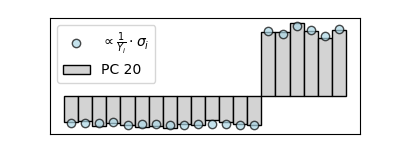

In [44]:
''' Plot low-variance eigenvector against yields prediction '''
''' Plot low-variance eigenvector and inverse yields vector, properly rescaled '''
data_std = np.std(data,axis=0)

# Rescaled inv_yields by species standard deviation
true_eigenvector = inv_yields[2,:]*data_std

# Make rescaled inv_yields a unitary vector
true_eigenvector /= np.sqrt(np.sum(true_eigenvector**2))


fig,ax = plt.subplots(figsize=(4,1.5))
ax.bar(np.arange(N_species),
       -true_lowvar_eigvects[:,0],
       edgecolor='k',facecolor='lightgray',
       width=1,label='PC 20')

ax.scatter(np.arange(N_species),
       true_eigenvector,alpha=0.7,zorder=2,
       edgecolor='k',color='lightblue',
       # width=1,
       # label='True'
       label=r'$\propto \frac{1}{Y_i} \cdot \sigma_i$'
      )
plt.legend()
ax.set_xticks([])
ax.set_yticks([])
format='svg'
plt.savefig('low_variance_eigenmode.vs_true.{}.{}'.format(dataset_name,format),transparent=True,format=format)